In [1]:
from typing import TypedDict

class ReviewState(TypedDict):
    generated_text: str

In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

def review_node(state: ReviewState):
    # 사용자(검토자)에게 생성된 콘텐츠를 편집하도록 요청
    updated = interrupt({
        "instruction": "이 콘텐츠를 검토하고 편집하세요",
        "content": state["generated_text"],
    })
    return {"generated_text": updated}


graph_builder = StateGraph(ReviewState)

graph_builder.add_node("review", review_node)
graph_builder.add_edge(START, "review")
graph_builder.add_edge("review", END)

checkpointer = InMemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

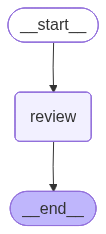

In [3]:
graph

In [4]:
config = {"configurable": {"thread_id": "review-1"}}
initial = graph.invoke({"generated_text": "초기 초안"}, config=config)
initial

{'generated_text': '초기 초안',
 '__interrupt__': [Interrupt(value={'instruction': '이 콘텐츠를 검토하고 편집하세요', 'content': '초기 초안'}, id='ef352ee943ae8a3d0be6f1cf5d3b99b5')]}

In [5]:
state = graph.get_state(config)
state

StateSnapshot(values={'generated_text': '초기 초안'}, next=('review',), config={'configurable': {'thread_id': 'review-1', 'checkpoint_ns': '', 'checkpoint_id': '1f166f3a-6999-61ad-8000-5212d98c7f7e'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-13T06:46:48.336426+00:00', parent_config={'configurable': {'thread_id': 'review-1', 'checkpoint_ns': '', 'checkpoint_id': '1f166f3a-6991-6d62-bfff-6fe8e7e33eff'}}, tasks=(PregelTask(id='4f83c93f-117f-68d4-ded8-5bfe938f749c', name='review', path=('__pregel_pull', 'review'), error=None, interrupts=(Interrupt(value={'instruction': '이 콘텐츠를 검토하고 편집하세요', 'content': '초기 초안'}, id='ef352ee943ae8a3d0be6f1cf5d3b99b5'),), state=None, result=None),), interrupts=(Interrupt(value={'instruction': '이 콘텐츠를 검토하고 편집하세요', 'content': '초기 초안'}, id='ef352ee943ae8a3d0be6f1cf5d3b99b5'),))

In [6]:
prompt = state.interrupts[0].value
print(prompt)
user_input = input(" > ")

{'instruction': '이 콘텐츠를 검토하고 편집하세요', 'content': '초기 초안'}


In [7]:
final_state = graph.invoke(
    Command(resume=user_input),
    config=config
)
final_state

{'generated_text': '수정 완료'}